# Estatísticas do corpus

Estatísticas do corpus final: quantidade de questões por subárea e por ano,
tokens, types, tamanho das questões, distribuição do gabarito e termos mais frequentes.

In [1]:
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

with open("corpus/corpus.json", encoding="utf-8") as f:
    questoes = json.load(f)["questoes"]

nomes = {
    "engenharia_de_software_e_programacao": "Eng. Software e Programação",
    "redes_e_infraestrutura": "Redes e Infraestrutura",
    "seguranca_da_informacao": "Segurança da Informação",
    "banco_de_dados_e_ciencia_de_dados": "Banco de Dados e Ciência de Dados",
    "governanca_e_gestao_de_ti": "Governança e Gestão de TI",
}
AZUL = "#2a78d6"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

## Tokenização

In [2]:
TOKEN = re.compile(r"\w+(?:[-.'’]\w+)*")

def tokenizar(texto):
    return TOKEN.findall(texto)

df = pd.DataFrame([{
    "id": q["id"],
    "subarea": nomes[q["subarea"]],
    "ano": q["ano"],
    "gabarito": q["gabarito"],
    "n_alternativas": len(q["alternativas"]),
    "enunciado": q["enunciado"],
    "texto": q["enunciado"] + " " + " ".join(a["texto"] for a in q["alternativas"]),
} for q in questoes])

df["tokens"] = df["texto"].apply(tokenizar)
df["n_tokens"] = df["tokens"].apply(len)
df["n_tokens_enunciado"] = df["enunciado"].apply(lambda t: len(tokenizar(t)))
df.head()

,id,subarea,ano,gabarito,n_alternativas,enunciado,texto,tokens,n_tokens,n_tokens_enunciado
0,01-037,Banco de Dados e Ciência de Dados,2021,C,5,Considere a propriedade de Isolamento das tran...,Considere a propriedade de Isolamento das tran...,"[Considere, a, propriedade, de, Isolamento, da...",39,34
1,01-041,Banco de Dados e Ciência de Dados,2021,C,5,Considere um banco de dados que contém uma tab...,Considere um banco de dados que contém uma tab...,"[Considere, um, banco, de, dados, que, contém,...",63,53
2,02-032,Banco de Dados e Ciência de Dados,2021,B,5,"No contexto do ambiente Android, considere as ...","No contexto do ambiente Android, considere as ...","[No, contexto, do, ambiente, Android, consider...",68,54
3,02-043,Banco de Dados e Ciência de Dados,2021,C,5,"Com referência ao MongoDB, nas consultas usand...","Com referência ao MongoDB, nas consultas usand...","[Com, referência, ao, MongoDB, nas, consultas,...",25,20
4,02-044,Banco de Dados e Ciência de Dados,2021,E,5,Considere um projeto de banco de dados no qual...,Considere um projeto de banco de dados no qual...,"[Considere, um, projeto, de, banco, de, dados,...",99,65


## Visão geral

In [3]:
todos_tokens = [t for lista in df["tokens"] for t in lista]
types = set(t.lower() for t in todos_tokens)
maior = df.loc[df["n_tokens"].idxmax()]
menor = df.loc[df["n_tokens"].idxmin()]

geral = pd.Series({
    "Questões": len(df),
    "Total de tokens": len(todos_tokens),
    "Total de types": len(types),
    "Razão type/token": round(len(types) / len(todos_tokens), 4),
    "Tokens por questão (média)": round(df["n_tokens"].mean(), 2),
    "Tokens por questão (mediana)": df["n_tokens"].median(),
    "Tokens por questão (desvio padrão)": round(df["n_tokens"].std(), 2),
    "Maior questão (tokens)": f'{maior["n_tokens"]} ({maior["id"]})',
    "Menor questão (tokens)": f'{menor["n_tokens"]} ({menor["id"]})',
    "Tokens no enunciado (média)": round(df["n_tokens_enunciado"].mean(), 2),
    "Questões com 5 alternativas": (df["n_alternativas"] == 5).sum(),
    "Questões com 4 alternativas": (df["n_alternativas"] == 4).sum(),
})
geral.to_frame("valor")

,valor
Questões,2506
Total de tokens,267403
Total de types,16988
Razão type/token,0.0635
Tokens por questão (média),106.71
Tokens por questão (mediana),98.5
Tokens por questão (desvio padrão),52.62
Maior questão (tokens),400 (56-044)
Menor questão (tokens),14 (94-044)
Tokens no enunciado (média),66.77


## Questões por subárea

In [4]:
por_subarea = df.groupby("subarea").agg(
    questoes=("id", "count"),
    tokens=("n_tokens", "sum"),
    media_tokens=("n_tokens", "mean"),
).sort_values("questoes", ascending=False)
por_subarea["%"] = (100 * por_subarea["questoes"] / len(df)).round(1)
por_subarea["types"] = [len({t.lower() for lista in df[df["subarea"] == s]["tokens"] for t in lista})
                        for s in por_subarea.index]
por_subarea["media_tokens"] = por_subarea["media_tokens"].round(1)
por_subarea

,questoes,tokens,media_tokens,%,types
subarea,,,,,
Eng. Software e Programação,758,80172,105.8,30.2,8517
Redes e Infraestrutura,664,70366,106.0,26.5,7533
Segurança da Informação,507,57259,112.9,20.2,6483
Banco de Dados e Ciência de Dados,459,46167,100.6,18.3,6046
Governança e Gestão de TI,118,13439,113.9,4.7,2293


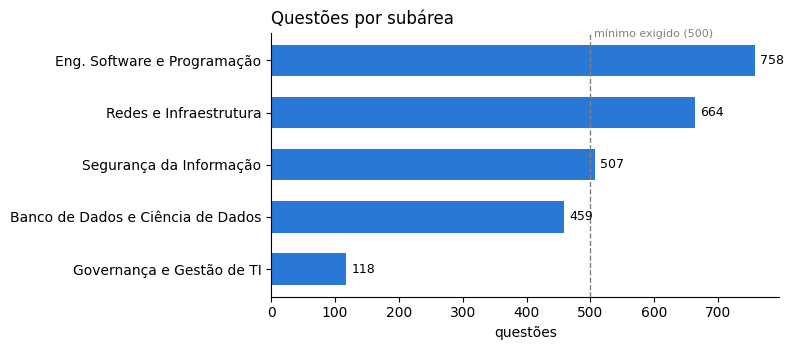

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
dados = por_subarea["questoes"][::-1]
ax.barh(dados.index, dados.values, color=AZUL, height=0.6)
ax.axvline(500, color="gray", ls="--", lw=1)
ax.text(505, 4.45, "mínimo exigido (500)", color="gray", fontsize=8)
for i, v in enumerate(dados.values):
    ax.text(v + 8, i, str(v), va="center", fontsize=9)
ax.set_xlabel("questões")
ax.set_title("Questões por subárea", loc="left")
plt.tight_layout()
plt.show()

## Questões por subárea e ano

In [6]:
tabela_ano = pd.crosstab(df["subarea"], df["ano"], margins=True, margins_name="Total")
tabela_ano = tabela_ano.loc[list(por_subarea.index) + ["Total"]]
tabela_ano

ano,2021,2022,2023,2024,2025,2026,Total
subarea,,,,,,,
Eng. Software e Programação,39,79,152,278,132,78,758
Redes e Infraestrutura,28,79,168,279,85,25,664
Segurança da Informação,16,67,97,233,56,38,507
Banco de Dados e Ciência de Dados,16,48,120,177,80,18,459
Governança e Gestão de TI,1,18,26,50,19,4,118
Total,100,291,563,1017,372,163,2506


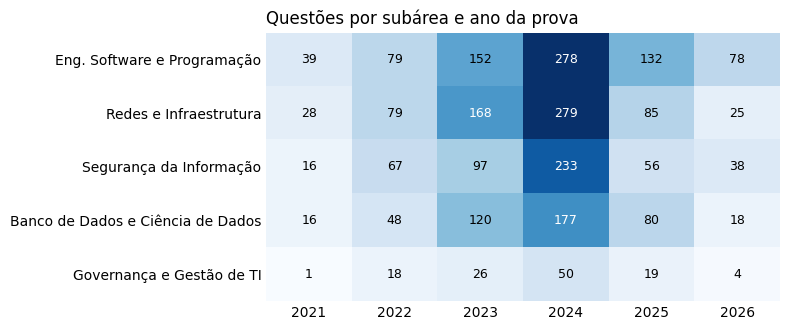

In [7]:
matriz = tabela_ano.drop(index="Total", columns="Total")
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.imshow(matriz.values, cmap="Blues", aspect="auto")
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        v = matriz.values[i, j]
        ax.text(j, i, v, ha="center", va="center", fontsize=9,
                color="white" if v > 0.55 * matriz.values.max() else "black")
ax.set_xticks(range(len(matriz.columns)), matriz.columns)
ax.set_yticks(range(len(matriz.index)), matriz.index)
ax.set_title("Questões por subárea e ano da prova", loc="left")
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

## Tamanho das questões

In [8]:
df.groupby("subarea")["n_tokens"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
subarea,,,,,,,,
Banco de Dados e Ciência de Dados,459.0,100.6,51.1,20.0,65.5,91.0,126.0,399.0
Eng. Software e Programação,758.0,105.8,54.2,14.0,68.0,97.0,135.0,359.0
Governança e Gestão de TI,118.0,113.9,49.4,37.0,79.5,104.0,136.8,292.0
Redes e Infraestrutura,664.0,106.0,53.9,18.0,65.0,98.5,138.2,400.0
Segurança da Informação,507.0,112.9,49.9,19.0,76.0,105.0,138.0,318.0


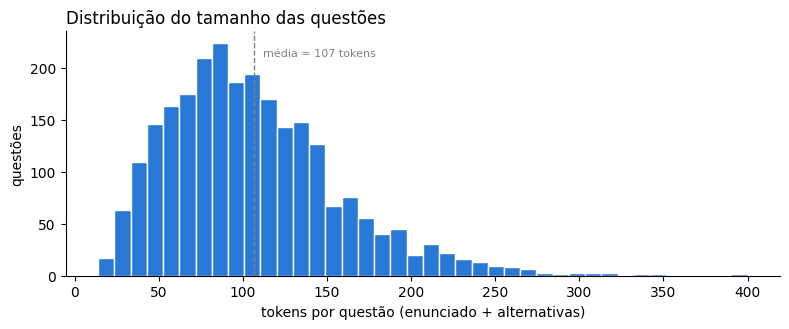

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(df["n_tokens"], bins=40, color=AZUL, edgecolor="white")
media = df["n_tokens"].mean()
ax.axvline(media, color="gray", ls="--", lw=1)
ax.text(media + 5, ax.get_ylim()[1] * 0.9, f"média = {media:.0f} tokens", color="gray", fontsize=8)
ax.set_xlabel("tokens por questão (enunciado + alternativas)")
ax.set_ylabel("questões")
ax.set_title("Distribuição do tamanho das questões", loc="left")
plt.tight_layout()
plt.show()

## Distribuição do gabarito

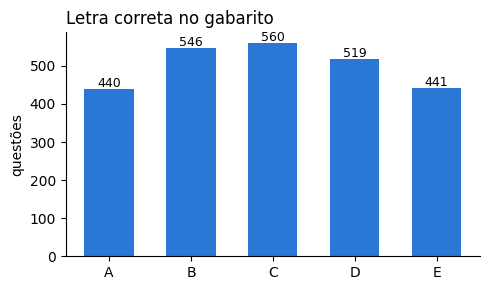

gabarito,A,B,C,D,E
questões,440,546,560,519,441


In [10]:
gab = df["gabarito"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(gab.index, gab.values, color=AZUL, width=0.6)
for letra, v in gab.items():
    ax.text(letra, v + 5, str(v), ha="center", fontsize=9)
ax.set_ylabel("questões")
ax.set_title("Letra correta no gabarito", loc="left")
plt.tight_layout()
plt.show()
gab.to_frame("questões").T

## Termos mais frequentes por subárea (sem stopwords)

In [11]:
stopwords = set("""a à ao aos as às o os um uma uns umas de da das do dos em na nas no nos por pela pelas pelo
pelos para com sem sob sobre entre e ou que se é são foi ser está estão como mais menos não sua seu suas seus
ele ela eles elas isso este esta esse essa estes essas esses qual quais quando onde já também apenas cada mesmo
muito pode podem deve devem ter tem têm há seguir seguinte seguintes assinale opção afirmativa afirmativas
correta correto corretas corretos analise considere item itens caso forma exemplo sendo respectivamente acordo
relação contexto termos todos todas ainda outro outra outros outras dessa desse deste desta nessa nesse neste
nesta""".split())

frequentes = {}
for s in por_subarea.index:
    palavras = [t.lower() for lista in df[df["subarea"] == s]["tokens"] for t in lista]
    palavras = [p for p in palavras if p not in stopwords and len(p) > 2 and not p.isdigit()]
    frequentes[s] = [p for p, _ in Counter(palavras).most_common(15)]
pd.DataFrame(frequentes)

,Eng. Software e Programação,Redes e Infraestrutura,Segurança da Informação,Banco de Dados e Ciência de Dados,Governança e Gestão de TI
0,código,rede,segurança,dados,serviços
1,software,dados,dados,banco,processos
2,desenvolvimento,iii,informação,from,projeto
3,iii,servidor,acesso,select,projetos
4,dados,sistema,rede,iii,iii
5,sistema,protocolo,pessoais,tabela,serviço
6,testes,redes,chave,sql,gerenciamento
7,projeto,nuvem,iii,bancos,gestão
8,web,sistemas,sistema,where,informação
9,uso,camada,riscos,data,processo


## Qualidade dos textos

Proporção de tokens alfabéticos (2 letras ou mais) que existem no dicionário de português ou de inglês do
`pyspellchecker` (`pip install pyspellchecker`). Siglas e termos técnicos (tcp, json,
kubernetes) e algumas palavras comuns que faltam no dicionário contam como não reconhecidos.

In [12]:
from spellchecker import SpellChecker

pt, en = SpellChecker(language="pt"), SpellChecker(language="en")
alfabeticos = [t.lower() for t in todos_tokens if re.fullmatch(r"[^\W\d_]{2,}", t)]
freq = Counter(alfabeticos)
conhecidos = {w for w in freq if w in pt or w in en}
reconhecidos = sum(n for w, n in freq.items() if w in conhecidos)

print(f"Tokens alfabéticos: {len(alfabeticos)}")
print(f"Reconhecidos: {reconhecidos} ({reconhecidos / len(alfabeticos):.1%})")
print("Não reconhecidos mais frequentes:",
      [w for w, _ in Counter({w: n for w, n in freq.items() if w not in conhecidos}).most_common(20)])

Tokens alfabéticos: 224546
Reconhecidos: 212642 (94.7%)
Não reconhecidos mais frequentes: ['gerenciamento', 'tcp', 'respectivamente', 'gerenciar', 'governança', 'int', 'dns', 'monitoramento', 'registros', 'registro', 'lgpd', 'iec', 'desenvolvedores', 'json', 'xpto', 'planejamento', 'nº', 'mysql', 'mpu', 'itil']
